# Correlation
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* Nazhin Nikkhahbahrami

*SID:* 810102530

The objective of this notebook is to understand the concept of correlation.


In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
import math
warnings.filterwarnings("ignore")

## Calculate Correlation
complete `correlation` function that calculate the correlation matridata of a data fram.

**Note:** you are not allowed to use `pandas.core.frame.DataFrame.corr()` method

In [111]:
#baray rahati moteghayer data=x
def correlation(x: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the correlation matrix from a given dataset.
    Args:
        data (pandas.core.frame.DataFrame): The dataset, where each row represents an observation and each column represents a feature.
    Returns:
        correlation_matrix (pandas.core.frame.DataFrame): The correlation matrix.
    """
     ######################  TODO  ########################
    n = len(x)
    means = {col: x[col].sum() / n for col in x.columns}
    correlation_matrix = pd.DataFrame(index=x.columns, columns=x.columns)
    
    for col1 in x.columns:
        for col2 in x.columns:
            covariance = sum((x[col1] - means[col1]) * (x[col2] - means[col2])) / (n - 1)
            std_dev_col1 = (sum((x[col1] - means[col1]) ** 2) / (n - 1)) ** 0.5
            std_dev_col2 = (sum((x[col2] - means[col2]) ** 2) / (n - 1)) ** 0.5
            if std_dev_col1 == 0 or std_dev_col2 == 0:  
                correlation = float('nan')
            else:
                correlation = covariance / (std_dev_col1 * std_dev_col2)
            correlation_matrix.loc[col1, col2] = correlation
    
    correlation_matrix = correlation_matrix.astype(float)
    return correlation_matrix
     ######################  TODO  ########################

### Convert to Datetime and Extract Features

In [112]:
######################  TODO  ########################
x = pd.read_csv('data/energy.csv')
x['Datetime'] = pd.to_datetime(x['Datetime'])
x['Year'] = x['Datetime'].dt.year
x['Month'] = x['Datetime'].dt.month
x['Hour'] = x['Datetime'].dt.hour
######################  TODO  ########################

file energy ra az data peyda karde va mikhanad bad doone doone datetime ra dakhel araye x mirizad va be sal va mah va saat tabdil mikonim va dakhel x mored nazar khodash mirizim.(part 1va 2)

### Plot Energy Usage Over Years

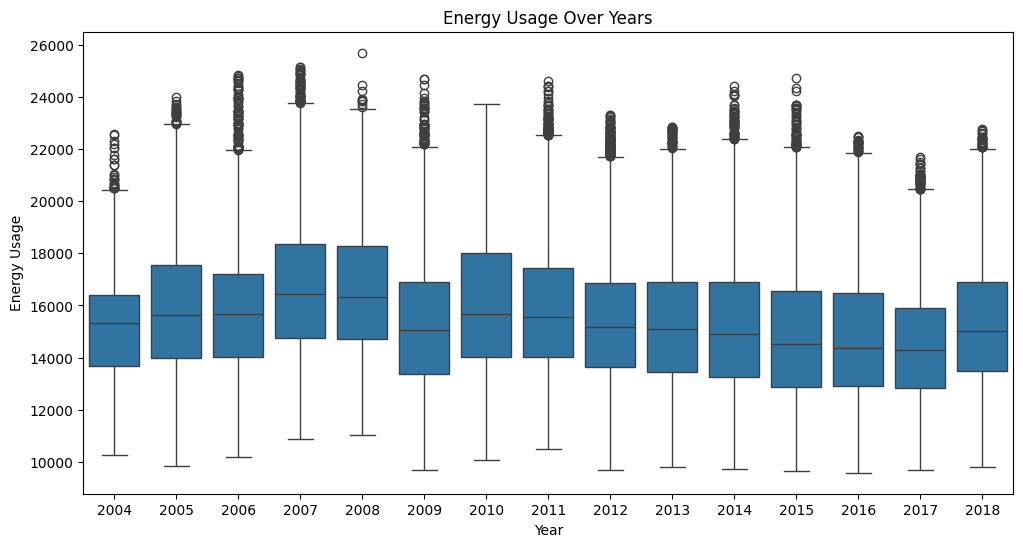

In [113]:
######################  TODO  ########################
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='AEP_MW', data=x)
plt.title('Energy Usage Over Years')
plt.xlabel('Year')
plt.ylabel('Energy Usage')
plt.show()
######################  TODO  ########################

ba tavajoh be "tarakom jabe 2005" ehtemalan dar 2005 variance bishtar ast. dar ghesmat bad  ba tabe var() tahlil mikonim.

### Analyze Energy Usage Over Years

In [114]:
######################  TODO  ########################
var_in_2004 = x[x['Year'] == 2004]['AEP_MW']
var_in_2005 = x[x['Year'] == 2005]['AEP_MW']
var_in_2004 = var_in_2004.var()
var_in_2005 = var_in_2005.var()
print(var_in_2004)
print(var_in_2005)
######################  TODO  ########################

4312554.64327797
6609516.545765586


banabarin variance sal 2005 bishtar ast.

### Plot Energy Usage Over Hours

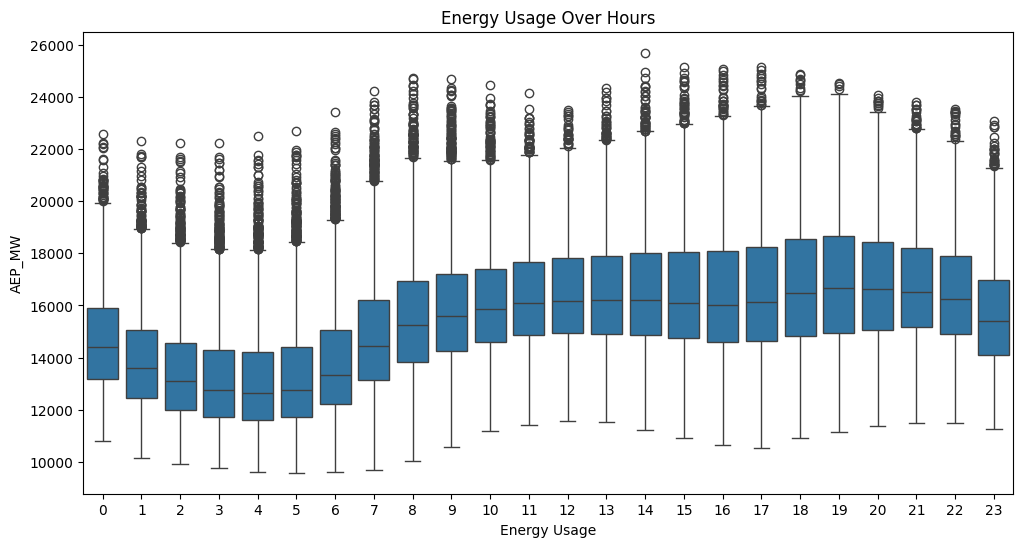

In [115]:
######################  TODO  ########################
plt.figure(figsize=(12, 6))
sns.boxplot(x='Hour', y='AEP_MW', data=x)
plt.title('Energy Usage Over Hours')
plt.xlabel('Energy Usage')
plt.show()
######################  TODO  ########################

tahlil nemoodar: saat hay avalie yani sobh masraf kamtar va bad ziad mishavad.

### Plot Energy Usage Over Months

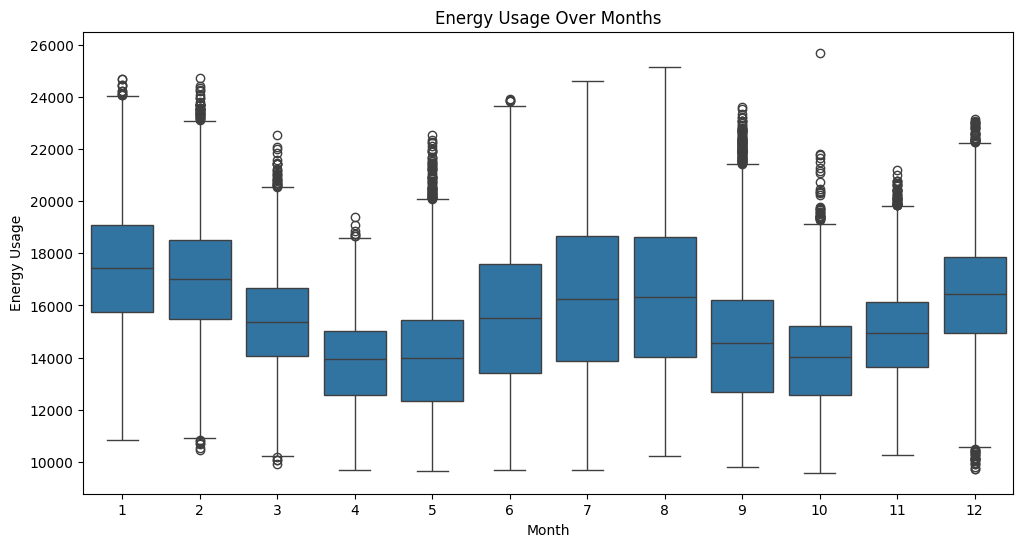

In [116]:
######################  TODO  ########################
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='AEP_MW', data=x)
plt.title('Energy Usage Over Months')
plt.xlabel('Month')
plt.ylabel('Energy Usage')
plt.show()
######################  TODO  ########################

dar mah hay miani masraf energy bishtar ast.

### Calculate Correlation Between Specific Hours and Energy Usage

In [117]:
######################  TODO  ########################
#part7                                       
energy= x[(x['Hour'] >= 4) & (x['Hour'] <= 13)]
correlation_matrix_hours= correlation (energy[['Hour','AEP_MW']])
print(correlation_matrix_hours)
######################  TO DO ########################
#part8
energy= x[(x['Month'] >= 2) & (x['Month'] <= 4)]
correlation_matrix_month1= correlation (energy[['Month','AEP_MW']])
energy= x[(x['Month'] >= 10) & (x['Month'] <= 12)]
correlation_matrix_month2= correlation (energy[['Month','AEP_MW']])
print(correlation_matrix_month1)
print(correlation_matrix_month2)
######################  TODO  ########################

            Hour    AEP_MW
Hour    1.000000  0.471379
AEP_MW  0.471379  1.000000
           Month    AEP_MW
Month   1.000000 -0.558245
AEP_MW -0.558245  1.000000
           Month    AEP_MW
Month   1.000000  0.473838
AEP_MW  0.473838  1.000000


### Analyze Correlation Between Specific Hours and Energy Usage

TODO

hamantor ke az shelkl niz maalum bood, masraf  da saat avalie ebteda bishtar va bad kam. da mah ham avaset bishtar.

## Causal Effect

In [118]:
######################  TODO  ########################
x = pd.read_csv('data/TV_LE_Physician.csv')
numerical_columns = x.select_dtypes(include=['float64', 'int64'])
correlation_matrix = correlation(numerical_columns)
correlation_matrix.to_csv('correlation_matrix.csv')
print(correlation_matrix)
######################  TODO  ########################

                             Life Expectancy (years)  \
Life Expectancy (years)                     1.000000   
Physicians per 1000 people                  0.628805   
Televisions per 1000 people                 0.025875   

                             Physicians per 1000 people  \
Life Expectancy (years)                        0.628805   
Physicians per 1000 people                     1.000000   
Televisions per 1000 people                    0.008602   

                             Televisions per 1000 people  
Life Expectancy (years)                         0.025875  
Physicians per 1000 people                      0.008602  
Televisions per 1000 people                     1.000000  


steps of the part above:
 Load the dataset(reding it)
 Select numerical columns only(select_dtypes)
 Using the correlation matrix using the custom correlation function(in part1 we create it)
 Use the correlation function
 Save the correlation matrix to a CSV file
 print correlations


TV Consumption and Life Expectancy:rabete bein anha gheirmostaghim ast hata momken ast asar manfi ham bogzarad ama dar mavared komak konande TV asar mokhareb kamtar ast.

Physician and Life Expectancy: correlation+. tedad pezeshkan bishtar mitavanad baes afzayesh omid be zendegi ast.

TV Consumption and Physician Availability:  correlation kam(bar asas javab part balayi). banabarin tedad pezeshkan va TV ertebati ba ham nadarand. masalan khastegi az didan TV aslan ruy tedad pezeshk asar nadard. shayad baes morajee kamtar shavad.


mitavan goft: correlation va rabete elat o maluli be ham mortabet hastand va mitavan az ham natije gereft